In [1]:
import pickle
from tools import *

features_path = './data/features'
returns_path = './data'

# 收益率
with open(f'{returns_path}/monthly_returns.pkl', 'rb') as f:
    ret = pickle.load(f)
# mcap
with open(f'{features_path}/mcap.pkl', 'rb') as f:
    mcap = pickle.load(f)
# book_value
with open(f'{features_path}/book_value_mrq.pkl', 'rb') as f:
    book = pickle.load(f)
# profit on asset 
with open(f'{features_path}/operating_profit_to_book_value_ttm.pkl', 'rb') as f:
    roe = pickle.load(f)
# asset growth 资产变化率
with open(f'{features_path}/asset_growth_mrq.pkl', 'rb') as f:
    ast_grth = pickle.load(f)


C:\Users\jason\AppData\Local\Temp\ipykernel_29568\973753672.py:9: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  ret = pickle.load(f)
C:\Users\jason\AppData\Local\Temp\ipykernel_29568\973753672.py:12: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functio

##### 模型限制为5因子模型（暂定）
##### pre/in/post = 2/6/2
##### 回测时间为2014-1 - 2023-12（暂定）
##### 训练时间为2016-1 - 2021-12（暂定）

In [2]:
# 计算因子
market_return = ret.mean(axis=1)
f_mkt = ret.apply(lambda x: market_return, axis=0)
f_size = xs_zscore(mcap)
f_value = book / mcap
f_profit = roe.copy()
f_invest = ast_grth.copy()

                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     137.9
Date:                Mon, 01 Dec 2025   Prob (F-statistic):          1.42e-146
Time:                        17:35:35   Log-Likelihood:             1.4644e+05
No. Observations:              242679   AIC:                        -2.929e+05
Df Residuals:                  242673   BIC:                        -2.928e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0027      0.000      6.445      0.0

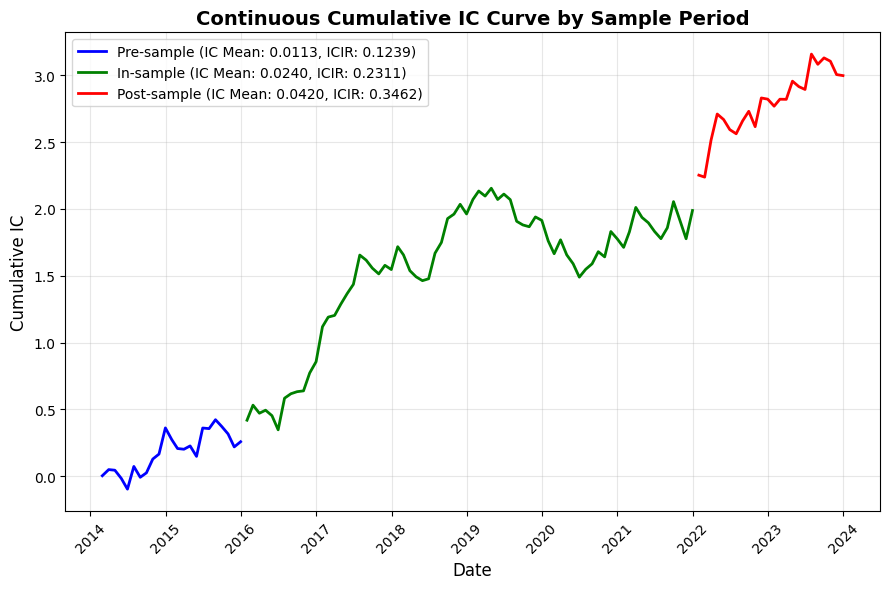

In [3]:

f_list = [f_mkt,f_size,f_value,f_profit,f_invest]

pre_sample = ('2014-01-01', '2015-12-31')
in_sample = ('2016-01-01', '2021-12-31')
post_sample = ('2022-01-01', '2023-12-31')
all_sample = ('2014-01-01', '2023-12-31')



next_period = OLS_regression(ret, f_list,in_sample)
ret_hat = linear_predict_returns(next_period, f_list, all_sample) # 预测收益率对到因子当天
ic_stats = calculate_ic_analysis(ret_hat.shift(1), ret, pre_sample, in_sample, post_sample)

                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     379.1
Date:                Mon, 01 Dec 2025   Prob (F-statistic):               0.00
Time:                        17:35:39   Log-Likelihood:             1.4815e+05
No. Observations:              243738   AIC:                        -2.963e+05
Df Residuals:                  243732   BIC:                        -2.962e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0189      0.000     45.688      0.0

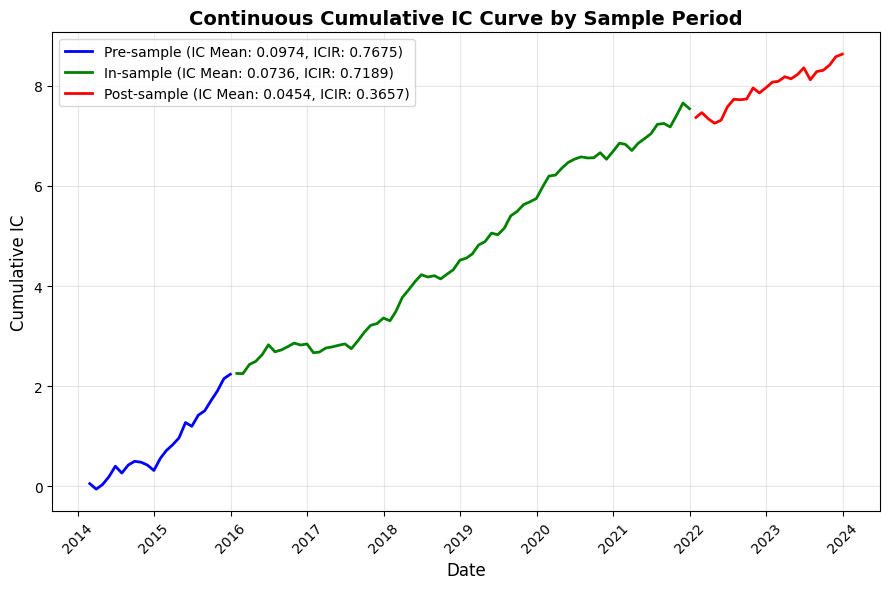

In [4]:
f_list_shift = [f_mkt,f_size,f_value.shift(-1),f_profit.shift(-1),f_invest.shift(-1)]
same_period = OLS_regression(ret, f_list_shift,in_sample)
ret_hat = linear_predict_returns(same_period, f_list_shift, all_sample)
ic_stats = calculate_ic_analysis(ret_hat.shift(1), ret, pre_sample, in_sample, post_sample) 